# Stationary Equilibrium

**Table of contents**<a id='toc0_'></a>
- 1. [Setup](#toc1_)
- 2. [Solve household problem](#toc2_)
- 3. [Find stationary equilibrium](#toc3_)
  - 3.1. [Direct approach](#toc3_1_)
  - 3.2. [Looking at the stationary equilibrium](#toc3_2_)    
    - 3.2.1. [Policy functions](#toc3_2_1_)    
    - 3.2.2. [Distributions](#toc3_2_2_)    
- 4. [Aggregate savings and the interest rate](#toc4_)    
- 5. [Idiosyncratic risk and the steady state interest rate](#toc5_)    
- 6. [Exercises: other ways to find the steady state](#toc6_)    
  - 6.1. [Guess the interest rate](#toc6_1_)    
  - 6.2. [Indirect method](#toc6_2_)    
  - 6.3. [Find the discount factor](#toc6_3_)    
- 7. [Matching the average MPC](#toc7_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

**Contents:**

1. Introduces the `GEModelTools`
1. Solves and simulates a simple **Heterogenous Agent Neo-Classical (HANC) model**

In [1]:
%load_ext autoreload
%autoreload 2

import time
import pickle
import numpy as np
from scipy import optimize

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from HANCModel import HANCModelClass

Generally, to use GEModelsTools, we need at least the following files and functions

1. `HANCModel.py`
    1. `settings()`: declare variables list
    2. `setup()`: set parameters
    3. `allocate()`: initialize all values
2. `household_problem.py`
    1. `solve_hh_backwards()` : one EGM step, (need to be attached in settings)
3. `blocks.py` : other aggregate functions definitions
4. `steady_state.py`
    1. `prepare_hh_ss()` : set grids, initial guess for distribution and value function
    2. `find_ss()` : solve for the steady-state (also need to be attached in settings)

and a notebook to run everything

## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [2]:
model = HANCModelClass(name='baseline') # create an instance of the model

In [3]:
model.path

namespace(a=array([[[[0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     ...,
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.]]],
            
            
                   [[[0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     ...,
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.]]],
            
            
                   [[[0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., ..., 0., 0., 0.],
                     ...,
                     [0., 0., 0., ..., 0., 0., 0.],
                     [0., 0., 0., 

In [4]:
par = model.par
ss = model.ss

In [5]:
ss.K

nan

In [6]:
print('Parameters in par:')
for name, val in vars(par).items():
    print(f'{name}: {val}')

Parameters in par:
Nfix: 1
Nz: 7
sigma: 1.0
beta: 0.9810226868872732
rho_z: 0.9
sigma_psi: 0.5
alpha: 0.3333333333333333
delta: 0.008333333333333331
Gamma_ss: 0.39685026299204984
a_max: 10000.0
Na: 500
r_ss_target: 0.0125
K_ss_target: 16.0
Y_ss_target: 1.0
labor_share_ss_target: 0.6666666666666666
max_iter_solve: 50000
max_iter_simulate: 100000
tol_solve: 1e-10
tol_simulate: 1e-12
T: 500
simT: 1000
max_iter_broyden: 100
tol_broyden: 1e-10
py_hh: True
py_blocks: True
full_z_trans: False
warnings: True
a_grid: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [7]:
for varname in model.varlist:
    print(f'{varname:15s}: {ss.__dict__[varname]:.4f}')

Gamma          : nan
K              : nan
L              : nan
rK             : nan
w              : nan
Y              : nan
A              : nan
r              : nan
A_hh           : nan
C_hh           : nan
L_hh           : nan
I              : nan
clearing_A     : nan
clearing_L     : nan
clearing_Y     : nan


**Pause:** Take a look at `.par` and `.ss`

**Question I:** Where does the variable names in `.ss` come from?

**Question II:** What explains the shapes below?

In [8]:
print(ss.a.shape)
print(ss.D.shape)
print(ss.z_trans.shape)

(1, 7, 500)
(1, 7, 500)
(1, 7, 7)


**Question III:** why is `ss.K = nan` for now?

## 2. <a id='toc2_'></a>[Solve household problem](#toc0_)

Set the steady state values, which matter for the household:

In [9]:
ss.r = 0.05 / 4
ss.w = 2/3

**Solve the household problem** with `.solve_hh_ss()`:
    
1. Calls `.prepare_hh_ss()`
1. Calls `.solve_backwards_hh()` until convergence

In [10]:
model.solve_hh_ss(do_print=True)

household problem in ss solved in 0.1 secs [1040 iterations]


In [11]:
model.simulate_hh_ss(do_print=True)

household problem in ss simulated in 0.7 secs [1132 iterations]


**Aggregate savings:**

In [12]:
np.sum(ss.a*ss.D)

np.float64(16.00000000000021)

## 3. <a id='toc3_'></a>[Find stationary equilibrium](#toc0_)

### 3.1. <a id='toc3_1_'></a>[Direct approach](#toc0_)

In [13]:
model.find_ss(K_min=10.0,K_max=18.5,do_print=True)

household problem in ss solved in 0.1 secs [1271 iterations]


household problem in ss simulated in 0.4 secs [15879 iterations]
K =  10.0000, r =  0.0202, w =  0.5700, clearing_A = -9998.08589371

household problem in ss solved in 0.1 secs [917 iterations]
household problem in ss simulated in 0.0 secs [900 iterations]
K =  18.5000, r =  0.0106, w =  0.6997, clearing_A =   4.86097520

household problem in ss solved in 0.1 secs [917 iterations]


household problem in ss simulated in 0.0 secs [900 iterations]
K =  18.4959, r =  0.0106, w =  0.6997, clearing_A =   4.85413146

household problem in ss solved in 0.1 secs [1067 iterations]
household problem in ss simulated in 0.0 secs [1195 iterations]
K =  15.5675, r =  0.0129, w =  0.6606, clearing_A =  -1.06441277



household problem in ss solved in 0.1 secs [1034 iterations]
household problem in ss simulated in 0.0 secs [1119 iterations]
K =  16.0942, r =  0.0124, w =  0.6680, clearing_A =   0.21956568

household problem in ss solved in 0.1 secs [1039 iterations]
household problem in ss simulated in 0.0 secs [1131 iterations]
K =  16.0041, r =  0.0125, w =  0.6667, clearing_A =   0.00968249



household problem in ss solved in 0.1 secs [1040 iterations]
household problem in ss simulated in 0.0 secs [1132 iterations]
K =  16.0000, r =  0.0125, w =  0.6667, clearing_A =  -0.00000124

household problem in ss solved in 0.1 secs [1040 iterations]
household problem in ss simulated in 0.0 secs [1132 iterations]
K =  16.0000, r =  0.0125, w =  0.6667, clearing_A =   0.00000000



household problem in ss solved in 0.1 secs [1040 iterations]
household problem in ss simulated in 0.0 secs [1132 iterations]
K =  16.0000, r =  0.0125, w =  0.6667, clearing_A =  -0.00000000

household problem in ss solved in 0.1 secs [1040 iterations]
household problem in ss simulated in 0.0 secs [1132 iterations]
K =  16.0000, r =  0.0125, w =  0.6667, clearing_A =   0.00000000



**Look at the steady state variables:**

In [14]:
for varname in model.varlist:
    print(f'{varname:15s}: {ss.__dict__[varname]:.4f}')


Gamma          : 0.3969
K              : 16.0000
L              : 1.0000
rK             : 0.0208
w              : 0.6667
Y              : 1.0000
A              : 16.0000
r              : 0.0125
A_hh           : 16.0000
C_hh           : 0.8667
L_hh           : 1.0000
I              : 0.1333
clearing_A     : 0.0000
clearing_L     : 0.0000
clearing_Y     : 0.0000


In [15]:
model.info(ss=True)

settings:
 par.py_hh = True
 par.py_blocks = True
 par.full_z_trans = False
 par.warnings = True
 par.T = 500

households:
 grids_hh: [a]
 pols_hh: [a]
 inputs_hh: [r,w]
 inputs_hh_z: []
 outputs_hh: [a,c]
 intertemps_hh: [vbeg_a]

aggregate:
 shocks: []
 unknowns: []
 targets: []

blocks (inputs -> outputs):
 production_firm: [] -> [Gamma=0.40,K=16.00,L=1.00,rK=0.02,w=0.67,Y=1.00]
 mutual_fund: [K=16.00,rK=0.02] -> [A=16.00,r=0.01]
 hh: [r=0.01,w=0.67] -> [A_hh=16.00,C_hh=0.87]
 market_clearing: [A=16.00,A_hh=16.00,L=1.00,Y=1.00,C_hh=0.87,K=16.00] -> [L_hh=1.00,I=0.13,clearing_A=0.00,clearing_L=0.00,clearing_Y=0.00]


**Question**: Try to add `ss.q = np.nan` in `obj_ss` in `steady_state.py` and run the code again. What happens? Why?

### 3.2. <a id='toc3_2_'></a>[Looking at the stationary equilibrium](#toc0_)

#### 3.2.1. <a id='toc3_2_1_'></a>[Policy functions](#toc0_)

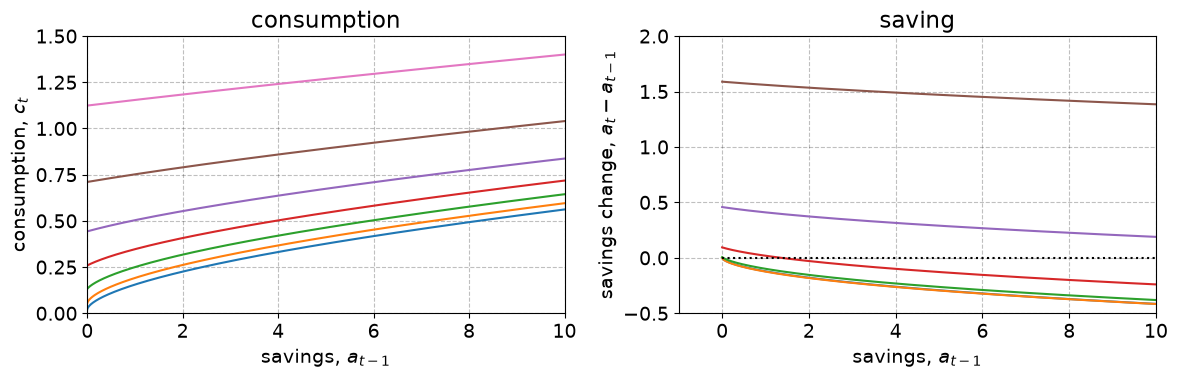

In [16]:
fig = plt.figure(figsize=(12,4),dpi=100)

I = par.a_grid < 500

# a. consumption
ax = fig.add_subplot(1,2,1)
ax.set_title(f'consumption')

for i_z,z in enumerate(par.z_grid):
    ax.plot(par.a_grid[I],ss.c[0,i_z,I],label=f'z = {z:.2f}')

#ax.legend(frameon=False)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')
ax.set_xlim(0,10)
ax.set_ylim(0,1.5)

# b. saving
ax = fig.add_subplot(1,2,2)
ax.set_title(f'saving')

for i_z,z in enumerate(par.z_grid):
    ax.plot(par.a_grid[I],ss.a[0,i_z,I]-par.a_grid[I],label=f'z = {z:.2f}')

ax.plot(np.zeros_like(par.a_grid), color = 'black', linestyle = ':')
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings change, $a_{t}-a_{t-1}$')
ax.set_xlim(-1,10)
ax.set_ylim(-0.5,2.0)

fig.tight_layout()
fig.savefig(f'figs/c_func.pdf')

#### 3.2.2. <a id='toc3_2_2_'></a>[Distributions](#toc0_)

/var/folders/5y/y0kmzv413w713jjqr0sf92ym0000gn/T/ipykernel_24609/596393570.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


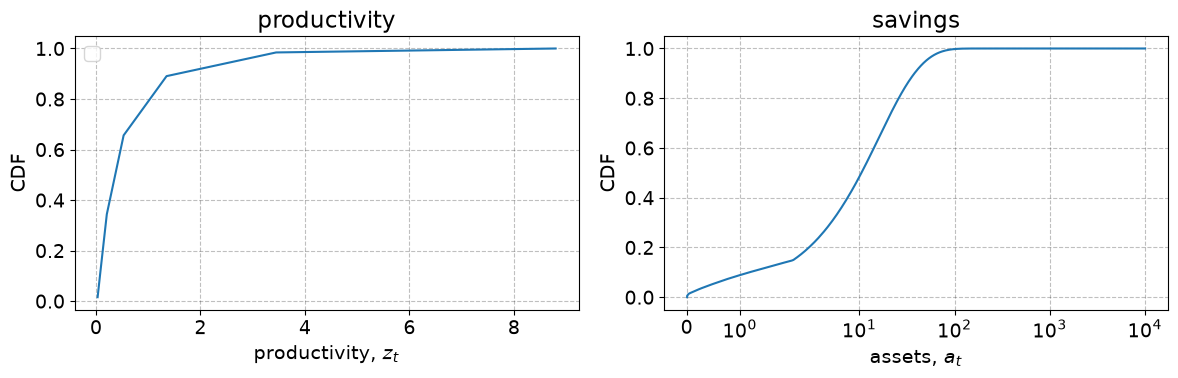

In [17]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

ax.plot(par.z_grid,np.cumsum(np.sum(ss.D[0],axis=1)))

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('CDF')
ax.legend()

# b. assets
ax = fig.add_subplot(1,2,2)
ax.set_title('savings')

ax.plot(np.insert(par.a_grid,0,par.a_grid[0]),np.insert(np.cumsum(np.sum(ss.D[0],axis=0)),0,0.0))
ax.set_xlabel('assets, $a_{t}$')
ax.set_ylabel('CDF')
ax.set_xscale('symlog')

fig.tight_layout()
fig.savefig('figs/distribution.pdf')

**Income moments:**

In [18]:
mean_z = np.sum(ss.D*par.z_grid[:,np.newaxis])
std_z = np.sqrt(np.sum(ss.D*(par.z_grid[np.newaxis,:,np.newaxis]-mean_z)**2))
print(f'mean z: {mean_z:5.2f}')
print(f'std. z: {std_z:5.2f}')

mean z:  1.00
std. z:  1.36


**Asset moments:**

In [19]:
# a. prepare
Da = np.sum(ss.D,axis=(0,1))


def get_share(D=None, a_grid=None, perc_bottom=0.0, perc_top=1.0):

    cdf = D.cumsum()
    wealth_cdf = (a_grid * D).cumsum()
    tot_wealth = (a_grid * D).sum()

    if perc_bottom == 0.0:
        wealth_bottom = 0.0
    else:
        wealth_bottom = np.interp(perc_bottom, cdf, wealth_cdf)

    if perc_top == 1.0:
        wealth_top = tot_wealth
    else:
        wealth_top = np.interp(perc_top, cdf, wealth_cdf)

    wealth = wealth_top - wealth_bottom
    share = wealth / tot_wealth

    return share

b50 = get_share(D=Da, a_grid=par.a_grid, perc_bottom=0.0, perc_top=0.5)
n40 = get_share(D=Da, a_grid=par.a_grid, perc_bottom=0.5, perc_top=0.9)
top10 = get_share(D=Da, a_grid=par.a_grid, perc_bottom=0.9, perc_top=1.0)
top100 = get_share(D=Da, a_grid=par.a_grid, perc_bottom=0.99, perc_top=1.0)
top1000 = get_share(D=Da, a_grid=par.a_grid, perc_bottom=0.999, perc_top=1.0)
top10000 = get_share(D=Da, a_grid=par.a_grid, perc_bottom=0.9999, perc_top=1.0)

wealth_shares = np.array([b50, n40, top10, top100, top1000, top10000]) * 100

In [20]:
import pandas as pd
df = pd.read_csv(
    '../wealth_psz.csv')
df = df[df['Year'] == 2019]

# Round 'value' column, convert to integer and drop 'Year' column

df['value'] = df['value'] * 100
df = df.drop(columns='Year')

# Add 'Model' column with wealth shares, round and convert to integer
df['Model'] = wealth_shares

# Rename 'value' column to 'Data PSZ'
df = df.rename(columns={'value': 'Data PSZ'})

# Pivot the DataFrame and reorder columns
df = pd.pivot_table(df, columns='Quantile', values=['Data PSZ', 'Model'])
df = df[['Bottom 50%', 'Middle 40%', 'Top 10%',
            'Top 1%', 'Top 0.1%', 'Top 0.01%']]

print(df.round(0))


Quantile  Bottom 50%  Middle 40%  Top 10%  Top 1%  Top 0.1%  Top 0.01%
Data PSZ         0.0        28.0     71.0    35.0      18.0        9.0
Model           14.0        52.0     35.0     6.0       1.0        0.0


We completely underestime the amount of wealth inequality observed in the US!

**MPC:**

In [21]:
def calc_MPC(par,ss):

    MPC = np.zeros(ss.D.shape)
    dc = (ss.c[:,:,1:]-ss.c[:,:,:-1])
    dm = (1+ss.r)*(par.a_grid[1:]-par.a_grid[:-1])
    MPC[:,:,:-1] = dc/dm
    MPC[:,:,-1] = MPC[:,:,-2]

    return MPC

MPC = calc_MPC(par,ss)

mean_MPC = np.sum(MPC*ss.D)
print(f'mean MPC: {mean_MPC:.3f}')

mean MPC: 0.044


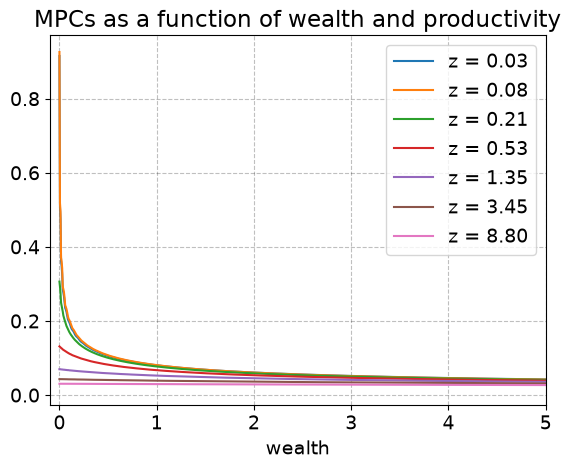

In [22]:
plt.plot(par.a_grid, MPC[0].T)
plt.xlim(-0.1, 5.0)
plt.legend([f'z = {z:.2f}' for z in par.z_grid])
plt.title('MPCs as a function of wealth and productivity')
plt.xlabel('wealth')
plt.show()

**Question:** What is the correlation between income and savings?

## 4. <a id='toc4_'></a>[Aggregate savings and the interest rate](#toc0_)

In [23]:
# allocate
Nr_ss = 10
r_ss_min = 0.04 / 4
r_ss_max = 0.065 / 4
r_ss_vec = np.linspace(r_ss_min,r_ss_max,Nr_ss)

K_hh_supply = np.zeros(Nr_ss)
K_firm_demand = np.zeros(Nr_ss)

# calculate
for i,r_ss in enumerate(r_ss_vec):

    print(f'{r_ss = :7.4f}')

    model_ = model.copy()
    model_.ss.r = r_ss

    # a. firms
    K_firm_demand[i] = ((r_ss+par.delta)/(par.alpha*ss.Gamma))**(1/(par.alpha-1))
    print(f'K_firm_demand = {K_firm_demand[i]:7.4f}')

    w_ss = model_.ss.w = (1.0-par.alpha)*ss.Gamma*(K_firm_demand[i]/ss.L)**par.alpha

    print(f'{w_ss = :7.4f}')

    # b. households
    model_.solve_hh_ss(do_print=True)
    model_.simulate_hh_ss(do_print=True)

    K_hh_supply[i] = np.sum(model_.ss.a*model_.ss.D)
    print(f'K_hh_supply = {K_hh_supply[i]:7.4f}')

    # c. clearing
    clearing_A = K_hh_supply[i]-K_firm_demand[i]
    print(f'{clearing_A = :7.4f}\n')


r_ss =  0.0100
K_firm_demand = 19.3819
w_ss =  0.7107


household problem in ss solved in 0.1 secs [885 iterations]
household problem in ss simulated in 0.0 secs [849 iterations]
K_hh_supply = 13.1173
clearing_A = -6.2646

r_ss =  0.0107


K_firm_demand = 18.3306
w_ss =  0.6976
household problem in ss solved in 0.1 secs [924 iterations]
household problem in ss simulated in 0.0 secs [911 iterations]
K_hh_supply = 13.7526
clearing_A = -4.5779

r_ss =  0.0114
K_firm_demand = 17.3710
w_ss =  0.6852


household problem in ss solved in 0.1 secs [966 iterations]
household problem in ss simulated in 0.0 secs [984 iterations]
K_hh_supply = 14.4996
clearing_A = -2.8714

r_ss =  0.0121
K_firm_demand = 16.4923
w_ss =  0.6734
household problem in ss solved in 0.1 secs [1011 iterations]
household problem in ss simulated in 0.0 secs [1071 iterations]
K_hh_supply = 15.3859
clearing_A = -1.1064

r_ss =  0.0128
K_firm_demand = 15.6853
w_ss =  0.6623


household problem in ss solved in 0.1 secs [1060 iterations]
household problem in ss simulated in 0.0 secs [1177 iterations]
K_hh_supply = 16.4501
clearing_A =  0.7649

r_ss =  0.0135
K_firm_demand = 14.9420
w_ss =  0.6516
household problem in ss solved in 0.1 secs [1111 iterations]
household problem in ss simulated in 0.0 secs [1307 iterations]
K_hh_supply = 17.7477
clearing_A =  2.8058

r_ss =  0.0142


K_firm_demand = 14.2556
w_ss =  0.6415
household problem in ss solved in 0.1 secs [1165 iterations]
household problem in ss simulated in 0.0 secs [1472 iterations]
K_hh_supply = 19.3613
clearing_A =  5.1057

r_ss =  0.0149
K_firm_demand = 13.6202
w_ss =  0.6318


household problem in ss solved in 0.1 secs [1214 iterations]
household problem in ss simulated in 0.0 secs [1688 iterations]
K_hh_supply = 21.4193
clearing_A =  7.7992

r_ss =  0.0156
K_firm_demand = 13.0306
w_ss =  0.6226
household problem in ss solved in 0.1 secs [1247 iterations]


household problem in ss simulated in 0.1 secs [1982 iterations]
K_hh_supply = 24.1340
clearing_A = 11.1034

r_ss =  0.0163
K_firm_demand = 12.4824
w_ss =  0.6137
household problem in ss solved in 0.1 secs [1262 iterations]


household problem in ss simulated in 0.1 secs [2426 iterations]
K_hh_supply = 27.8863
clearing_A = 15.4039



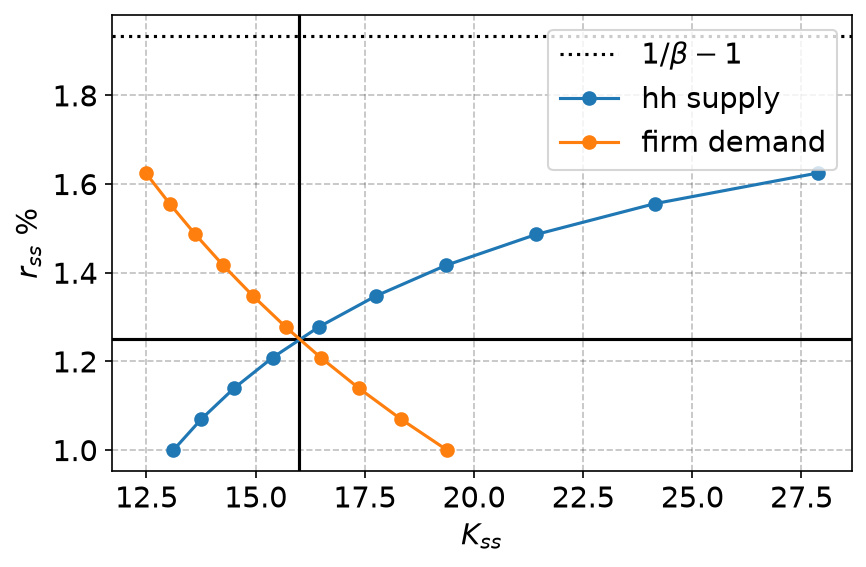

In [24]:
fig = plt.figure(figsize=(6,6/1.5),dpi=150)
ax = fig.add_subplot(1,1,1)

ax.axhline(ss.r*100,color='black')
ax.axhline((1/model.par.beta-1)*100,color='black', linestyle = ':', label = '$1/\\beta - 1$')
ax.axvline(ss.K,color='black')

ax.plot(K_hh_supply,  r_ss_vec*100,'-o',label='hh supply')
ax.plot(K_firm_demand,r_ss_vec*100,'-o',label='firm demand')

ax.set_ylabel('$r_{ss}$ %')
ax.set_xlabel('$K_{ss}$')
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig('figs/market_clearing.pdf')

## 5. <a id='toc5_'></a>[Idiosyncratic risk and the steady state interest rate](#toc0_)

In [25]:
print(f'ss.A_hh = ss.K = {ss.A_hh:.2f}')
print(f'ss.r = {ss.r*100:.2f} %')
print('')

N_psi = 10
psi_vec = np.linspace(0.5*par.sigma_psi,1.5*par.sigma_psi,N_psi)
A_pe_vec = np.zeros((N_psi))
A_ge_vec = np.zeros((N_psi))


for i, sigma_psi in enumerate(psi_vec):

    print(f'{sigma_psi = :.2f}')

    model_ = model.copy()
    model_.par.sigma_psi = sigma_psi

    model_.ss.r = model.ss.r # original interest rate in our calibration
    model_.ss.w = model.ss.w # original wage in our calibration
    model_.solve_hh_ss(do_print=False)
    model_.simulate_hh_ss(do_print=False)

    # Save the PE aggregate assets in the array
    A_pe_vec[i] = np.sum(model_.ss.a*model_.ss.D)

    print(f'PE {A_pe_vec[i] = :.2f}')

    # Solve the mode again in GE (find K such that A-K=0)
    model_.find_ss(K_min=1.0,K_max=30.0)

    # Save the GE aggregate assets in the array
    A_ge_vec[i] = model_.ss.A_hh

    print(f'GE ss.r = {model_.ss.r*100:.2f} %')
    print(f'GE ss.A_hh = ss.K = {model_.ss.A_hh:.2f}')

    print('')


ss.A_hh = ss.K = 16.00
ss.r = 1.25 %

sigma_psi = 0.25


PE A_pe_vec[i] = 4.92


GE ss.r = 1.71 %
GE ss.A_hh = ss.K = 11.87

sigma_psi = 0.31
PE A_pe_vec[i] = 7.12


GE ss.r = 1.61 %
GE ss.A_hh = ss.K = 12.58

sigma_psi = 0.36
PE A_pe_vec[i] = 9.52


GE ss.r = 1.51 %
GE ss.A_hh = ss.K = 13.43

sigma_psi = 0.42
PE A_pe_vec[i] = 12.05


...

GE ss.r = 1.20 %
GE ss.A_hh = ss.K = 16.57

sigma_psi = 0.58
PE A_pe_vec[i] = 20.01


GE ss.r = 1.11 %
GE ss.A_hh = ss.K = 17.76

sigma_psi = 0.64
PE A_pe_vec[i] = 22.69


GE ss.r = 1.02 %
GE ss.A_hh = ss.K = 18.99

sigma_psi = 0.69
PE A_pe_vec[i] = 25.33


GE ss.r = 0.95 %
GE ss.A_hh = ss.K = 20.24

sigma_psi = 0.75
PE A_pe_vec[i] = 27.93


GE ss.r = 0.88 %
GE ss.A_hh = ss.K = 21.50



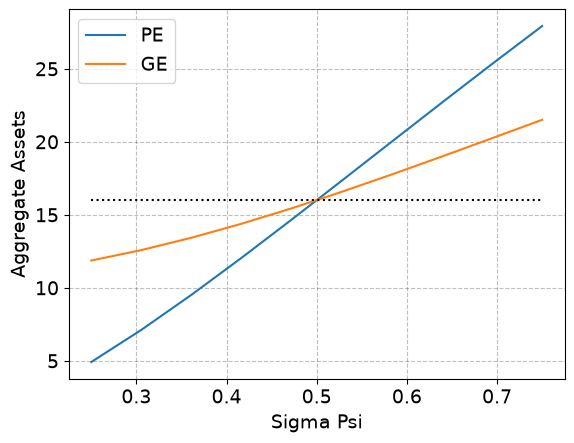

In [26]:
plt.plot(psi_vec, A_pe_vec)
plt.plot(psi_vec, A_ge_vec)
plt.plot(psi_vec, np.ones_like(A_ge_vec) * model.ss.K, color = 'black', linestyle = ':')
plt.xlabel('Sigma Psi')
plt.ylabel('Aggregate Assets')
plt.legend(['PE', 'GE'])
plt.savefig('figs/sigma_psi_vs_A.pdf')
plt.show()

## 6. <a id='toc6_'></a>[Exercises: other ways to find the steady state](#toc0_)

`find_ss` in `steady_state.py` guesses $K$ and finds the root of the asset market clearing error. The same stationary equilibrium can be found in other ways. Write each method below as a plain function of `model`, using `obj_ss` and `find_ss` as templates. The only toolbox calls you need are `model.solve_hh_ss()` and `model.simulate_hh_ss()`.

Each exercise is followed by its solution and a test cell. Skip the solution cell to test your own code. Always work on a copy of the model, because some methods change the parameters.

### 6.1. <a id='toc6_1_'></a>[Guess the interest rate](#toc0_)

Guess $r$ instead of $K$ (slide *Direct implementation (r guess)*). Invert the firm first-order condition to get $K$ from $r$, then proceed as in `obj_ss`. You must find the same equilibrium as with the guess on $K$.

In [27]:
def obj_ss_r(r_ss,model,do_print=False):
    """ asset market clearing error for a guess on the steady state interest rate """

    par = model.par
    ss = model.ss

    # a. firms: set ss.r, ss.rK, ss.L, ss.L_hh, ss.Gamma, ss.K, ss.A, ss.Y, ss.w

    # b. households: solve and simulate

    # c. market clearing: set ss.I, ss.clearing_A, ss.clearing_L, ss.clearing_Y

    return ss.clearing_A

def find_ss_r(model,r_min,r_max,do_print=False):
    """ find the steady state with a root-finder on the interest rate """

    # call optimize.brentq on obj_ss_r

**Solution:**

In [28]:
def obj_ss_r(r_ss,model,do_print=False):
    """ asset market clearing error for a guess on the steady state interest rate """

    par = model.par
    ss = model.ss

    # a. firms
    ss.r = r_ss
    ss.rK = ss.r+par.delta
    ss.L = ss.L_hh = 1.0
    ss.Gamma = par.Gamma_ss
    ss.K = ss.A = (ss.rK/(par.alpha*ss.Gamma))**(1/(par.alpha-1.0))*ss.L
    ss.Y = ss.Gamma*ss.K**par.alpha*ss.L**(1-par.alpha)
    ss.w = (1.0-par.alpha)*ss.Gamma*(ss.K/ss.L)**par.alpha

    # b. households
    model.solve_hh_ss(do_print=do_print)
    model.simulate_hh_ss(do_print=do_print)

    # c. market clearing
    ss.I = par.delta*ss.K
    ss.clearing_A = ss.A-ss.A_hh
    ss.clearing_L = ss.L-ss.L_hh
    ss.clearing_Y = ss.Y-ss.C_hh-ss.I

    if do_print: print(f'r = {ss.r:7.4f}, K = {ss.K:8.4f}, w = {ss.w:7.4f}, clearing_A = {ss.clearing_A:12.8f}\n')

    return ss.clearing_A

def find_ss_r(model,r_min,r_max,do_print=False):
    """ find the steady state with a root-finder on the interest rate """

    optimize.brentq(obj_ss_r,r_min,r_max,args=(model,do_print))

In [29]:
model_r = model.copy()
find_ss_r(model_r,r_min=0.005,r_max=0.018)

print(f'K = {model_r.ss.K:.4f}, r = {model_r.ss.r*100:.4f} %')
assert np.isclose(model_r.ss.K,model.ss.K)

K = 16.0000, r = 1.2500 %


**Question:** What happens if you set `r_max` above $1/\beta-1$? Why?

### 6.2. <a id='toc6_2_'></a>[Indirect method](#toc0_)

No root-finder (slide *Indirect implementation*). Fix $r$ at `par.r_ss_target` and $w$ at `(1-par.alpha)*par.Y_ss_target`, solve the household problem once, and let household savings determine $K$. Then back out the $\Gamma$ and $\delta$ that make the firm first-order conditions hold.

In [30]:
def find_ss_indirect(model,do_print=False):
    """ find the steady state by fixing prices and backing out Gamma and delta """

    par = model.par
    ss = model.ss

    # a. targets: set ss.L, ss.L_hh, ss.r, ss.w

    # b. households: solve and simulate

    # c. capital is what households save: set ss.K, ss.A

    # d. back out technology and depreciation: set ss.Gamma, par.Gamma_ss, ss.rK, par.delta

    # e. remaining variables: set ss.Y, ss.I, ss.clearing_A, ss.clearing_L, ss.clearing_Y

**Solution:**

In [31]:
def find_ss_indirect(model,do_print=False):
    """ find the steady state by fixing prices and backing out Gamma and delta """

    par = model.par
    ss = model.ss

    # a. targets
    ss.L = ss.L_hh = 1.0
    ss.r = par.r_ss_target
    ss.w = (1-par.alpha)*par.Y_ss_target/ss.L

    # b. households
    model.solve_hh_ss(do_print=do_print)
    model.simulate_hh_ss(do_print=do_print)

    # c. capital is what households save
    ss.K = ss.A = ss.A_hh

    # d. back out technology and depreciation
    ss.Gamma = par.Gamma_ss = ss.w/((1-par.alpha)*(ss.K/ss.L)**par.alpha)
    ss.rK = par.alpha*ss.Gamma*(ss.K/ss.L)**(par.alpha-1.0)
    par.delta = ss.rK-ss.r

    # e. remaining variables
    ss.Y = ss.Gamma*ss.K**par.alpha*ss.L**(1-par.alpha)
    ss.I = par.delta*ss.K
    ss.clearing_A = ss.A-ss.A_hh
    ss.clearing_L = ss.L-ss.L_hh
    ss.clearing_Y = ss.Y-ss.C_hh-ss.I

In [32]:
model_indirect = model.copy()
model_indirect.par.sigma_psi = 0.6
find_ss_indirect(model_indirect)

print(f'K = {model_indirect.ss.K:.4f}, Gamma = {model_indirect.par.Gamma_ss:.4f}, delta = {model_indirect.par.delta:.4f}')
print(f'baseline: K = {model.ss.K:.4f}, Gamma = {model.par.Gamma_ss:.4f}, delta = {model.par.delta:.4f}')
assert np.isclose(model_indirect.ss.clearing_A,0.0)
assert np.isclose(model_indirect.ss.clearing_Y,0.0,atol=1e-6)

K = 20.8181, Gamma = 0.3635, delta = 0.0035
baseline: K = 16.0000, Gamma = 0.3969, delta = 0.0083


**Question:** We raised income risk to `sigma_psi = 0.6`. With the direct method $K$ and $r$ would adjust. What adjusts here instead?

### 6.3. <a id='toc6_3_'></a>[Find the discount factor](#toc0_)

Calibration as root-finding (slide *Direct implementation ($\beta$)*). We have four targets, stored in `par`, and we pick one parameter for each:

| Parameter | Target | How |
|---|---|---|
| $\alpha$ | labor share $w L/Y=2/3$ (`par.labor_share_ss_target`) | closed form, $\alpha=1-wL/Y$ |
| $\Gamma$ | $Y=1$ (`par.Y_ss_target`) | closed form, $\Gamma=Y/(K^{\alpha}L^{1-\alpha})$ |
| $\delta$ | $r=0.05/4$ (`par.r_ss_target`) | closed form, $\delta=\alpha Y/K-r$ |
| $\beta$ | $K/Y=16$ (`par.K_ss_target`) | root-finder: households must want to hold exactly $A=K$ |

The first three follow from the firm first-order conditions, as in the indirect method. Only $\beta$ requires solving the household problem.

In [33]:
def obj_ss_beta(beta,model,do_print=False):
    """ asset market clearing error for a guess on the discount factor """

    par = model.par
    ss = model.ss

    # a. set par.beta

    # b. households: solve and simulate

    # c. market clearing: set ss.clearing_A

    return ss.clearing_A

def find_ss_beta(model,beta_min,beta_max,do_print=False):
    """ calibrate alpha, Gamma, delta and beta to the targets for the labor share, Y, r and K """

    par = model.par
    ss = model.ss

    # a. targets: set ss.L, ss.L_hh, ss.Y, ss.K, ss.A, ss.r

    # b. parameters with a closed form: set par.alpha, ss.Gamma, par.Gamma_ss, ss.rK, par.delta, ss.w

    # c. call optimize.brentq on obj_ss_beta

    # d. remaining variables: set ss.I, ss.clearing_L, ss.clearing_Y

**Solution:**

In [34]:
def obj_ss_beta(beta,model,do_print=False):
    """ asset market clearing error for a guess on the discount factor """

    par = model.par
    ss = model.ss

    par.beta = beta

    model.solve_hh_ss(do_print=do_print)
    model.simulate_hh_ss(do_print=do_print)

    ss.clearing_A = ss.A-ss.A_hh

    if do_print: print(f'beta = {par.beta:7.4f}, clearing_A = {ss.clearing_A:12.8f}\n')

    return ss.clearing_A

def find_ss_beta(model,beta_min,beta_max,do_print=False):
    """ calibrate alpha, Gamma, delta and beta to the targets for the labor share, Y, r and K """

    par = model.par
    ss = model.ss

    # a. targets
    ss.L = ss.L_hh = 1.0
    ss.Y = par.Y_ss_target
    ss.K = ss.A = par.K_ss_target
    ss.r = par.r_ss_target

    # b. parameters with a closed form: alpha from the labor share, Gamma from Y, delta from r
    par.alpha = 1-par.labor_share_ss_target
    ss.Gamma = par.Gamma_ss = ss.Y/(ss.K**par.alpha*ss.L**(1-par.alpha))
    ss.rK = par.alpha*ss.Y/ss.K
    par.delta = ss.rK-ss.r
    ss.w = (1-par.alpha)*ss.Y/ss.L

    # c. beta by root-finding: households must hold A = K
    optimize.brentq(obj_ss_beta,beta_min,beta_max,args=(model,do_print))

    # d. remaining variables
    ss.I = par.delta*ss.K
    ss.clearing_L = ss.L-ss.L_hh
    ss.clearing_Y = ss.Y-ss.C_hh-ss.I

In [35]:
model_beta = model.copy()
model_beta.par.K_ss_target = 12.0
find_ss_beta(model_beta,beta_min=0.5,beta_max=0.985)

par_beta = model_beta.par
ss_beta = model_beta.ss
print(f'alpha = {par_beta.alpha:.4f}, Gamma = {par_beta.Gamma_ss:.4f}, delta = {par_beta.delta:.4f}, beta = {par_beta.beta:.4f}')
print(f'baseline: alpha = {model.par.alpha:.4f}, Gamma = {model.par.Gamma_ss:.4f}, delta = {model.par.delta:.4f}, beta = {model.par.beta:.4f}')

assert np.isclose(ss_beta.w*ss_beta.L/ss_beta.Y,par_beta.labor_share_ss_target)
assert np.isclose(ss_beta.Y,par_beta.Y_ss_target)
assert np.isclose(ss_beta.r,par_beta.r_ss_target)
assert np.isclose(ss_beta.A_hh/ss_beta.Y,12.0)
assert np.isclose(ss_beta.clearing_Y,0.0,atol=1e-6)

alpha = 0.3333, Gamma = 0.4368, delta = 0.0153, beta = 0.9782
baseline: alpha = 0.3333, Gamma = 0.3969, delta = 0.0083, beta = 0.9810


**Question:** What are the pros and cons of the three methods?

## 7. <a id='toc7_'></a>[Matching the average MPC](#toc0_)

Choose `K` to get a chosen average MPC, recalibrating $\beta$ for each `K`. This uses `find_ss_beta` from exercise 3.

In [36]:
K_vec = np.linspace(0.5, 18.0, 10)
MPC_vec = np.zeros_like(K_vec)

model_K = model.copy()
for i, K in enumerate(K_vec):
    model_K.par.K_ss_target = K
    find_ss_beta(model_K,beta_min=0.5,beta_max=0.985)
    MPC_vec[i] = mean_MPC = (model_K.ss.D * calc_MPC(model_K.par,model_K.ss)).sum()


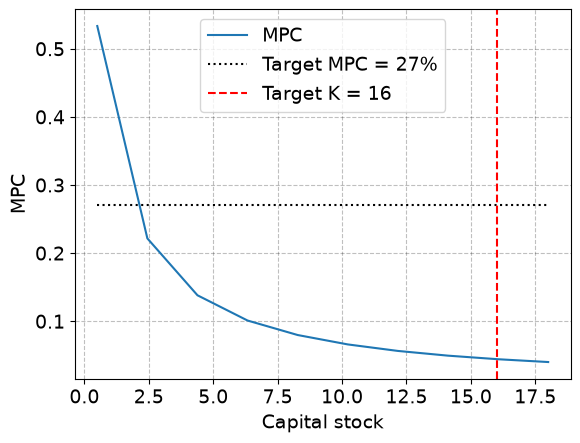

In [37]:
plt.plot(K_vec, MPC_vec)
plt.plot(K_vec, np.ones_like(MPC_vec)*0.27, color = 'black', linestyle = ':')
# add vertical line
plt.axvline(16.0, color = 'red', linestyle = '--')
plt.xlabel('Capital stock')
plt.ylabel('MPC')
plt.legend(['MPC', 'Target MPC = 27%','Target K = 16'])
plt.savefig('figs/MPC_vs_K.pdf')
plt.show()

In [38]:
def calib_obj(K,model):
    """ calibration objective """

    model.par.K_ss_target = K
    find_ss_beta(model,beta_min=0.5,beta_max=0.985)

    mean_MPC = (model.ss.D * calc_MPC(model.par,model.ss)).sum()
    print(mean_MPC)

    return mean_MPC-0.27

In [39]:
model_calib = model.copy()
optimize.brentq(calib_obj,0.5,16.0,args=(model_calib,),xtol=1e-8,rtol=1e-8);

0.5333307139192395


0.04429609040061911


0.07509154983561353


0.13111254982814713


0.21162920559154175


...

0.26856879101181474


0.2700100784727094


0.26999994698990964


0.2700000000034061


0.2699999984258593


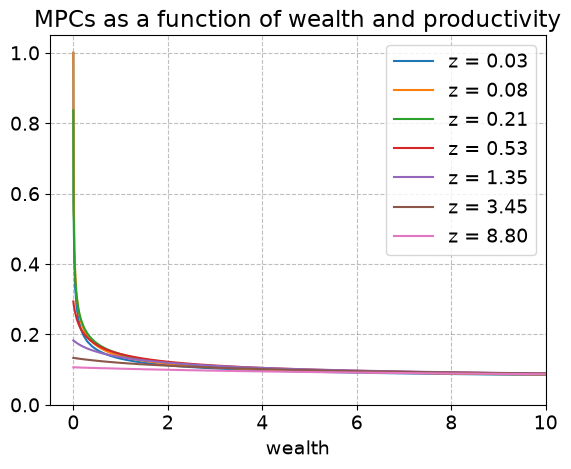

In [40]:
MPC = calc_MPC(par,model_calib.ss)

plt.plot(par.a_grid, MPC[0].T)
plt.xlim(-0.5, 10)
plt.ylim(0.0, 1.05)
plt.legend([f'z = {z:.2f}' for z in par.z_grid])
plt.title('MPCs as a function of wealth and productivity')
plt.xlabel('wealth')
plt.savefig('figs/MPC_policies.pdf')
plt.show()

In [41]:
print(f'ss.r = {model_calib.ss.r*100:.2f} %')
print(f'ss.K = {model_calib.ss.K:.2f}')
print(f'K/Y = {(model_calib.ss.K / model_calib.ss.Y):.2f}')

ss.r = 1.25 %
ss.K = 1.90
K/Y = 1.90
